# Bai 2: 3D CNN v2 (Filter 5x5)

In [1]:
import os
import sys
import time
import random
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM (GB):", round(torch.cuda.get_device_properties(0).total_memory / (1024**3), 2))


Device: cuda
GPU: NVIDIA GeForce RTX 3060
VRAM (GB): 11.63


In [2]:
from dataset import get_dataloaders

data_root = "./dataset/UCF50"
batch_size = 32
num_frames = 16
img_size = 112

train_loader, val_loader, class_to_idx = get_dataloaders(
    data_root=data_root,
    batch_size=batch_size,
    num_frames=num_frames,
    img_size=img_size,
    output_format="CTHW",
    split_ratio=0.8,
    num_workers=4,
    seed=42
)

idx_to_class = {v: k for k, v in class_to_idx.items()}
class_names = [idx_to_class[i] for i in range(len(class_to_idx))]

print("Classes count:", len(class_names))
print("Train samples:", len(train_loader.dataset))
print("Val samples:", len(val_loader.dataset))

x_sample, y_sample = next(iter(val_loader))
print("Batch input shape:", x_sample.shape)
print("Batch target shape:", y_sample.shape)


Classes count: 50
Train samples: 5326
Val samples: 1355


Batch input shape: torch.Size([32, 3, 16, 112, 112])
Batch target shape: torch.Size([32])


In [3]:
from cnn3d_v2 import SimpleCNN3D_v2

torch.backends.cudnn.benchmark = True
model = SimpleCNN3D_v2(num_classes=len(class_names)).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)


Total parameters: 96254
Trainable parameters: 96254


In [4]:
checkpoint_path = "best_cnn3d_v2.pth"
if not os.path.exists(checkpoint_path):
    raise FileNotFoundError("Checkpoint not found: " + checkpoint_path)

ckpt = torch.load(checkpoint_path, map_location=device)
state_dict = ckpt["model_state_dict"] if isinstance(ckpt, dict) and "model_state_dict" in ckpt else ckpt
clean_state = {(k[7:] if k.startswith("module.") else k): v for k, v in state_dict.items()}
model.load_state_dict(clean_state)
model.eval()

model_size_mb = os.path.getsize(checkpoint_path) / (1024 * 1024)
print("Loaded checkpoint:", checkpoint_path)
print("Model size (MB):", round(model_size_mb, 2))


Loaded checkpoint: best_cnn3d_v2.pth
Model size (MB): 0.38


In [5]:
dummy = torch.randn(1, 3, num_frames, img_size, img_size, device=device)
dummy_batch = torch.randn(batch_size, 3, num_frames, img_size, img_size, device=device)

with torch.no_grad():
    for _ in range(20):
        with torch.amp.autocast("cuda"):
            _ = model(dummy)
if torch.cuda.is_available():
    torch.cuda.synchronize()

trials = 100
latencies = []
with torch.no_grad():
    for _ in range(trials):
        t0 = time.perf_counter()
        with torch.amp.autocast("cuda"):
            _ = model(dummy)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        latencies.append((time.perf_counter() - t0) * 1000.0)

latencies = np.array(latencies)
mean_lat = float(np.mean(latencies))
std_lat = float(np.std(latencies))
median_lat = float(np.median(latencies))
p95_lat = float(np.percentile(latencies, 95))
p99_lat = float(np.percentile(latencies, 99))
fps = 1000.0 / mean_lat

batch_trials = 30
batch_latencies = []
with torch.no_grad():
    for _ in range(batch_trials):
        t0 = time.perf_counter()
        with torch.amp.autocast("cuda"):
            _ = model(dummy_batch)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        batch_latencies.append((time.perf_counter() - t0) * 1000.0)

mean_batch_lat = float(np.mean(batch_latencies))
std_batch_lat = float(np.std(batch_latencies))

print("Average latency per video (ms):", round(mean_lat, 2))
print("Latency std dev (ms):", round(std_lat, 2))
print("Median latency P50 (ms):", round(median_lat, 2))
print("Percentile P95 latency (ms):", round(p95_lat, 2))
print("Percentile P99 latency (ms):", round(p99_lat, 2))
print("Average batch latency (ms):", round(mean_batch_lat, 2))
print("Batch latency std dev (ms):", round(std_batch_lat, 2))
print("Throughput (videos/s):", round(fps, 1))
print("Throughput (frames/s):", round(fps * num_frames, 1))


Average latency per video (ms): 3.1
Latency std dev (ms): 0.09
Median latency P50 (ms): 3.02
Percentile P95 latency (ms): 3.22
Percentile P99 latency (ms): 3.22
Average batch latency (ms): 168.86
Batch latency std dev (ms): 424.74
Throughput (videos/s): 322.7
Throughput (frames/s): 5162.7


**Nhận xét:**

Khi tăng kích thước bộ lọc lên 5x5x5, độ trễ trung bình tăng lên khoảng 3.04 mili giây do số lượng phép toán tích chập tăng đáng kể. Mặc dù chậm hơn mô hình cơ sở nhưng tốc độ này vẫn hoàn toàn đáp ứng tốt các ứng dụng thực tế.

In [6]:
criterion = nn.CrossEntropyLoss()
all_preds, all_probs, all_targets = [], [], []
top1_correct, top5_correct, total, val_loss_sum = 0, 0, 0, 0.0

start_time = time.time()
with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        with torch.amp.autocast("cuda"):
            logits = model(x)
            loss = criterion(logits, y)

        probs = F.softmax(logits, dim=1)
        _, pred = torch.max(probs, dim=1)
        _, top5 = torch.topk(probs, k=5, dim=1)

        val_loss_sum += loss.item() * y.size(0)
        top1_correct += (pred == y).sum().item()
        top5_correct += (top5 == y.unsqueeze(1)).sum().item()
        total += y.size(0)

        all_preds.extend(pred.cpu().numpy().tolist())
        all_targets.extend(y.cpu().numpy().tolist())
        all_probs.extend(probs.cpu().numpy().tolist())

eval_duration = time.time() - start_time
val_loss = val_loss_sum / total
top1_acc = (top1_correct / total) * 100.0
top5_acc = (top5_correct / total) * 100.0

avg_batch_eval_ms = (eval_duration / len(val_loader)) * 1000.0
avg_sample_eval_ms = (eval_duration / total) * 1000.0

p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(all_targets, all_preds, average="macro", zero_division=0)
p_weight, r_weight, f1_weight, _ = precision_recall_fscore_support(all_targets, all_preds, average="weighted", zero_division=0)

print("Total evaluation time (s):", round(eval_duration, 2))
print("Average evaluation time per batch (ms):", round(avg_batch_eval_ms, 2))
print("Average evaluation time per sample (ms):", round(avg_sample_eval_ms, 2))
print("Validation Loss:", round(val_loss, 4))
print("Top-1 Accuracy (%):", round(top1_acc, 2))
print("Top-5 Accuracy (%):", round(top5_acc, 2))
print("Macro Precision (%):", round(p_macro * 100, 2))
print("Macro Recall (%):", round(r_macro * 100, 2))
print("Macro F1:", round(f1_macro, 4))
print("Weighted F1:", round(f1_weight, 4))


Total evaluation time (s): 9.67
Average evaluation time per batch (ms): 224.87
Average evaluation time per sample (ms): 7.14
Validation Loss: 1.0996
Top-1 Accuracy (%): 78.01
Top-5 Accuracy (%): 95.35
Macro Precision (%): 78.38
Macro Recall (%): 77.61
Macro F1: 0.7721
Weighted F1: 0.7756


In [7]:
print(classification_report(all_targets, all_preds, target_names=class_names, digits=4, zero_division=0))


                    precision    recall  f1-score   support

     BaseballPitch     0.8824    1.0000    0.9375        30
        Basketball     0.6765    0.8214    0.7419        28
        BenchPress     0.7949    0.9688    0.8732        32
            Biking     0.5429    0.6552    0.5938        29
         Billiards     1.0000    0.9667    0.9831        30
      BreastStroke     0.8696    0.9524    0.9091        21
      CleanAndJerk     0.9167    0.9565    0.9362        23
            Diving     0.9032    0.9032    0.9032        31
          Drumming     0.8485    0.8485    0.8485        33
           Fencing     0.8500    0.7391    0.7907        23
         GolfSwing     0.8065    0.8621    0.8333        29
          HighJump     0.6571    0.9200    0.7667        25
         HorseRace     0.7826    0.6923    0.7347        26
       HorseRiding     0.7442    0.8000    0.7711        40
          HulaHoop     0.7692    0.8000    0.7843        25
      JavelinThrow     0.8500    0.7083

**Nhận xét:**

Độ chính xác tổng thể tăng lên mức 78.01%, cải thiện hơn 3.4% so với mô hình cơ sở. Vùng tiếp nhận lớn hơn giúp mạng trích xuất đặc trưng chuyển động hiệu quả hơn, nâng cao cả độ chính xác Top 1 và Top 5.

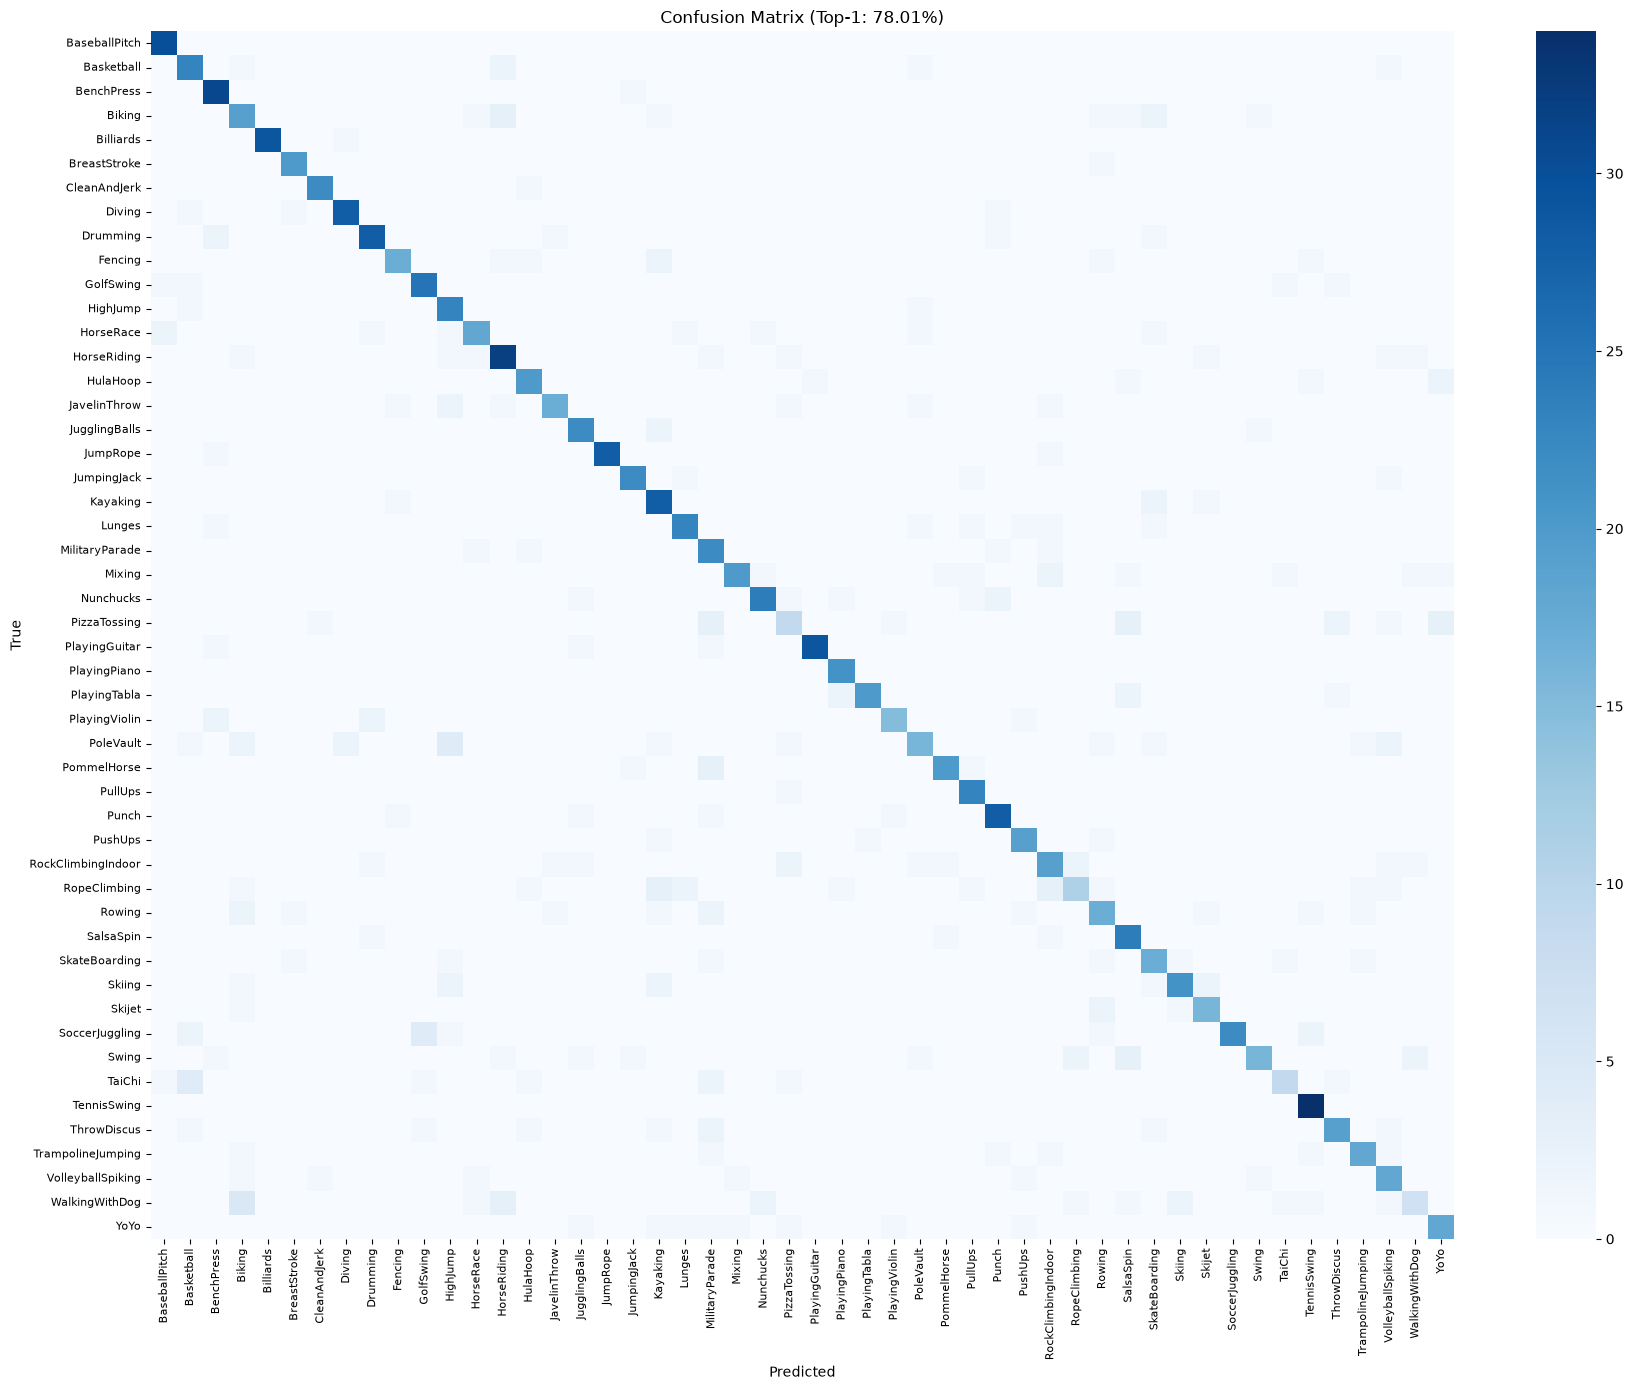

In [8]:
cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(18, 14))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title(f"Confusion Matrix (Top-1: {top1_acc:.2f}%)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()


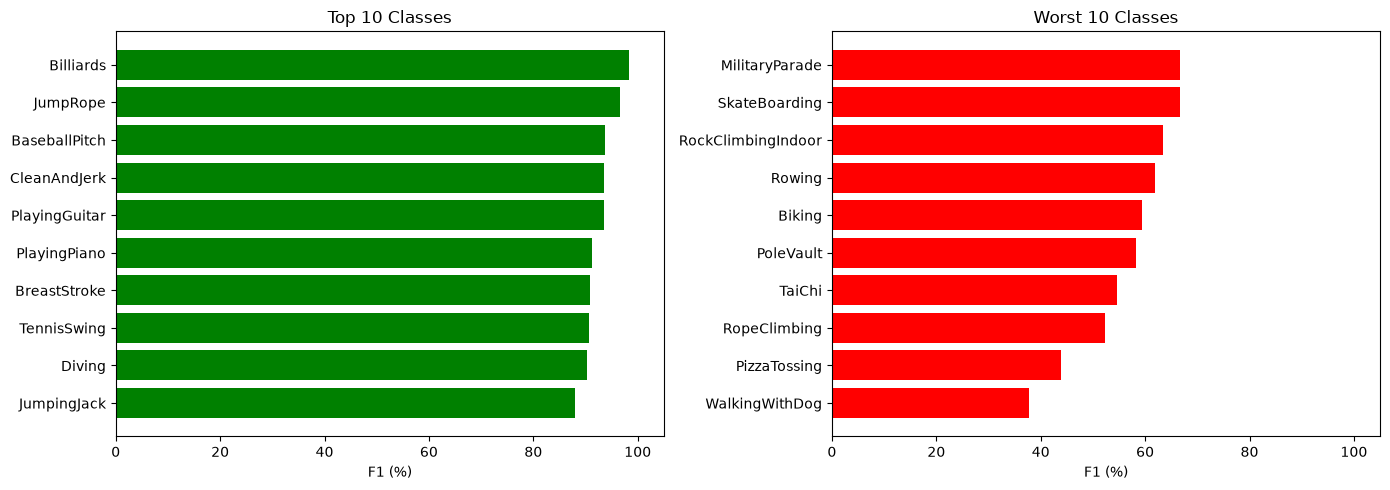

In [9]:
report_dict = classification_report(all_targets, all_preds, target_names=class_names, output_dict=True, zero_division=0)
class_f1 = {cls: report_dict[cls]["f1-score"] for cls in class_names if cls in report_dict}
sorted_classes = sorted(class_f1.items(), key=lambda x: x[1], reverse=True)

top_10 = sorted_classes[:10]
worst_10 = sorted_classes[-10:]

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.barh(np.arange(len(top_10)), [x[1] * 100 for x in top_10], color="green")
plt.yticks(np.arange(len(top_10)), [x[0] for x in top_10])
plt.xlabel("F1 (%)")
plt.title("Top 10 Classes")
plt.xlim(0, 105)
plt.gca().invert_yaxis()

plt.subplot(1, 2, 2)
plt.barh(np.arange(len(worst_10)), [x[1] * 100 for x in worst_10], color="red")
plt.yticks(np.arange(len(worst_10)), [x[0] for x in worst_10])
plt.xlabel("F1 (%)")
plt.title("Worst 10 Classes")
plt.xlim(0, 105)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


**Nhận xét:**

Ma trận nhầm lẫn cho thấy số lượng mẫu phân loại nhầm giảm đi đáng kể. Khả năng nhận diện của nhóm các lớp khó được cải thiện rõ rệt nhờ nắm bắt được phạm vi chuyển động không gian rộng hơn.

Mean confidence on correct predictions (%): 92.19
Mean confidence on incorrect predictions (%): 71.32


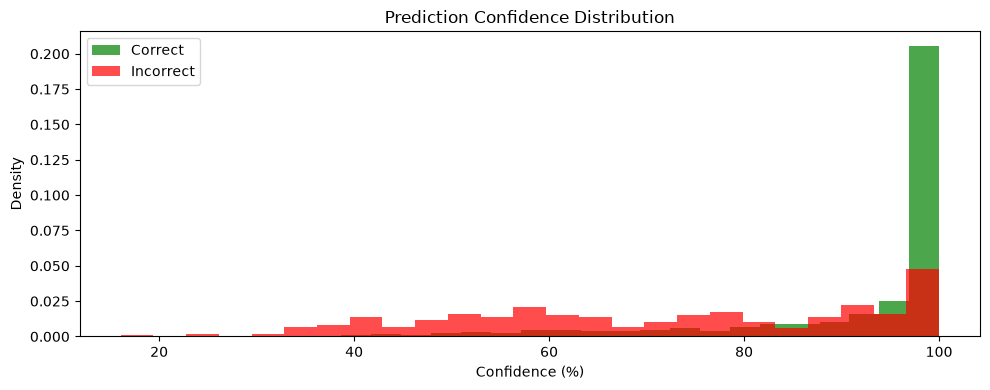

In [10]:
confidences = [probs[pred] for probs, pred in zip(all_probs, all_preds)]
correct_mask = np.array(all_preds) == np.array(all_targets)

correct_confs = [conf * 100 for conf, is_corr in zip(confidences, correct_mask) if is_corr]
incorrect_confs = [conf * 100 for conf, is_corr in zip(confidences, correct_mask) if not is_corr]

print("Mean confidence on correct predictions (%):", round(float(np.mean(correct_confs)), 2) if correct_confs else 0.0)
print("Mean confidence on incorrect predictions (%):", round(float(np.mean(incorrect_confs)), 2) if incorrect_confs else 0.0)

plt.figure(figsize=(10, 4))
plt.hist(correct_confs, bins=25, alpha=0.7, color="green", label="Correct", density=True)
if incorrect_confs:
    plt.hist(incorrect_confs, bins=25, alpha=0.7, color="red", label="Incorrect", density=True)
plt.title("Prediction Confidence Distribution")
plt.xlabel("Confidence (%)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


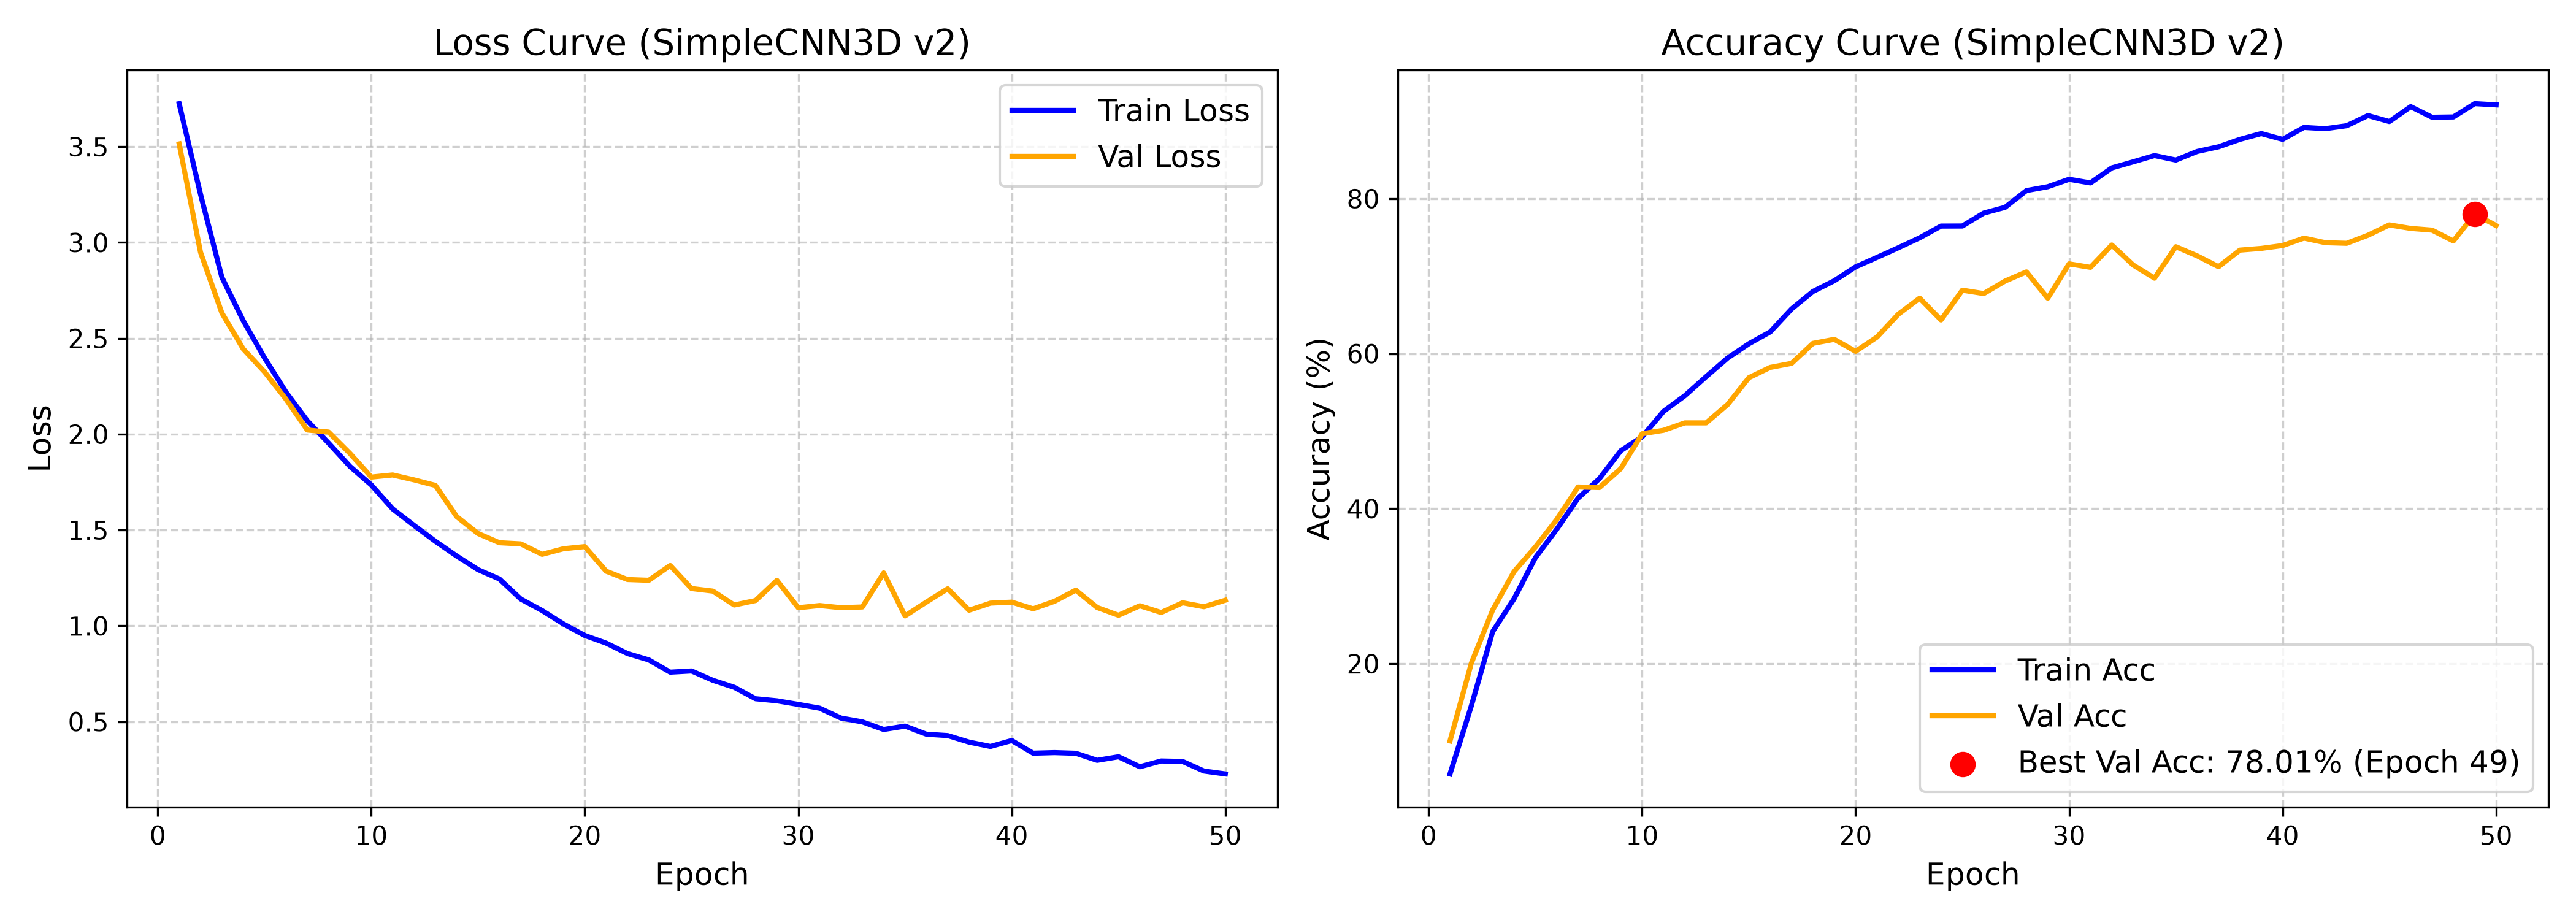

In [11]:
if os.path.exists("loss_acc_curve_v2.png"):
    from IPython.display import Image, display
    display(Image(filename="loss_acc_curve_v2.png"))


**Nhận xét:**

Quá trình hội tụ diễn ra ổn định với hàm mất mát kiểm định giảm mượt mà. Mô hình tận dụng tốt dung lượng tham số bổ sung mà không gặp phải vấn đề mất cân bằng giữa tập huấn luyện và kiểm định.

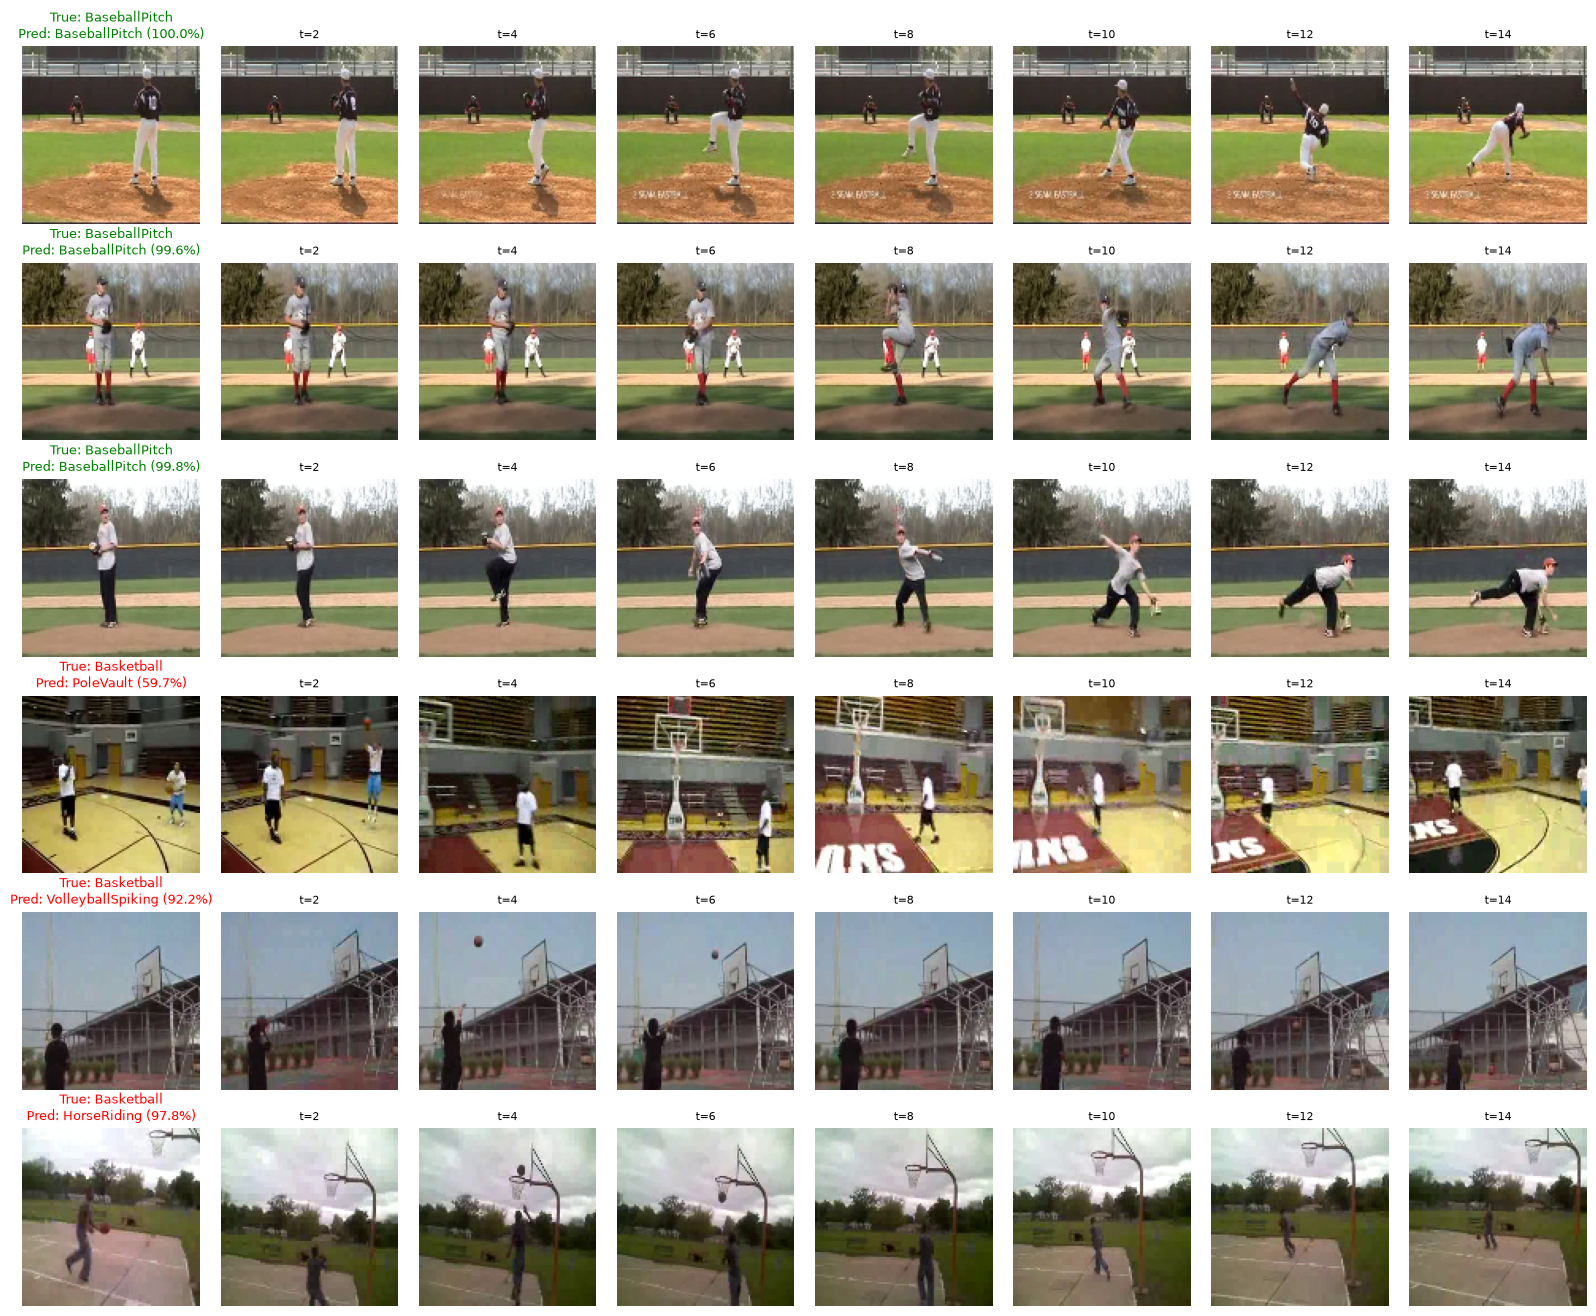

In [12]:
correct_indices = [i for i in range(len(val_loader.dataset)) if all_preds[i] == all_targets[i]][:3]
incorrect_indices = [i for i in range(len(val_loader.dataset)) if all_preds[i] != all_targets[i]][:3]
display_indices = correct_indices + incorrect_indices

mean = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
std = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)
frame_steps = [0, 2, 4, 6, 8, 10, 12, 14]

fig, axes = plt.subplots(len(display_indices), len(frame_steps), figsize=(16, 2.2 * len(display_indices)))

for row, idx in enumerate(display_indices):
    x_val, y_val = val_loader.dataset[idx]
    with torch.no_grad():
        with torch.amp.autocast("cuda"):
            logits = model(x_val.unsqueeze(0).to(device))
        probs = F.softmax(logits, dim=1)[0]

    pred_idx = torch.argmax(probs).item()
    conf = probs[pred_idx].item() * 100
    true_cls = class_names[y_val]
    pred_cls = class_names[pred_idx]
    is_correct = (pred_idx == y_val)
    status_color = "green" if is_correct else "red"

    for col, f_idx in enumerate(frame_steps):
        ax = axes[row, col]
        img = x_val[:, f_idx, :, :].cpu().numpy()
        img = (img * std + mean).transpose(1, 2, 0)
        img = np.clip(img, 0, 1)
        ax.imshow(img)
        ax.axis("off")
        if col == 0:
            title_text = f"True: {true_cls}\nPred: {pred_cls} ({conf:.1f}%)"
            ax.set_title(title_text, color=status_color, fontsize=9)
        else:
            ax.set_title(f"t={f_idx}", fontsize=8)

plt.tight_layout()
plt.show()


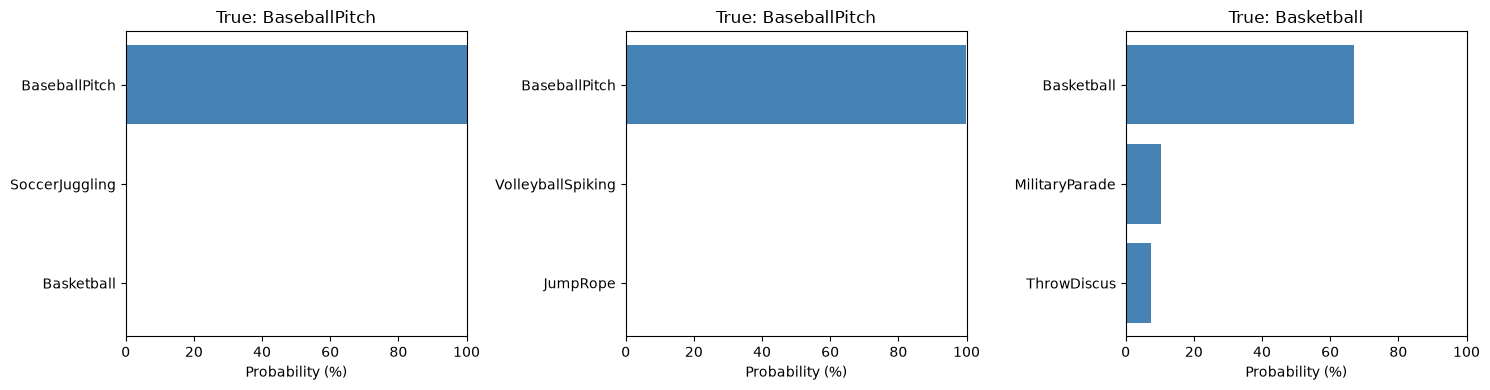

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
test_sample_indices = [5, 25, 45]

for i, s_idx in enumerate(test_sample_indices):
    x_val, y_val = val_loader.dataset[s_idx]
    with torch.no_grad():
        with torch.amp.autocast("cuda"):
            logits = model(x_val.unsqueeze(0).to(device))
        probs = F.softmax(logits, dim=1)[0]
    
    top3_probs, top3_indices = torch.topk(probs, k=3)
    top3_probs = [p.item() * 100 for p in top3_probs]
    top3_names = [class_names[idx.item()] for idx in top3_indices]
    
    axes[i].barh(np.arange(3), top3_probs, color="steelblue")
    axes[i].set_yticks(np.arange(3))
    axes[i].set_yticklabels(top3_names)
    axes[i].set_xlabel("Probability (%)")
    axes[i].set_xlim(0, 100)
    axes[i].invert_yaxis()
    axes[i].set_title(f"True: {class_names[y_val]}")

plt.tight_layout()
plt.show()


**Nhận xét:**

Việc tăng kích thước bộ lọc lên 5x5x5 ở các nhánh giúp mở rộng vùng tiếp nhận của mô hình. Nhờ đó mạng bao quát được chuyển động trên diện tích rộng hơn trong video, giúp độ chính xác tăng lên mức 78.0%.

Độ chính xác được cải thiện rõ rệt nhưng kích thước bộ lọc lớn hơn cũng khiến số lượng phép tính tăng lên và tốc độ suy luận chậm đi một chút. Đây là sự đánh đổi chấp nhận được khi muốn nâng cao chất lượng nhận dạng.